In [24]:
# Assignment module1
#   Plot a map showing the density of population of the towns in the province of Milano, in 2014.

In [108]:
# Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import num

In [30]:
# Load the "comuni" shapefile as a geopandas dataframe
shapefile = './Desktop/mod1_HadisForghani/REGIONE_LOMBARDIA_2020/Comuni_2020_poligonali.shp'
comuni = gpd.GeoDataFrame.from_file(shapefile)
comuni

,CLASSREF,BELFIORE,COD_ISTATN,NOME_COM,COD_PRO,NOME_PRO,SIG_PRO,COD_CMO,NOME_CMO,COD_ASL,...,ANNO,ISTAT,LEGGE_ISTI,ATS_COD,ATS_DEC,CMETR_COD,CMETR_DEC,SHAPE_AREA,SHAPE_LEN,geometry
0,0570159f-0e0f-4edd-824c-23388d03a009,I276,03018144,SANT`ANGELO LOMELLINA,18,PAVIA,PV,None,None,12,...,0,18144,None,030328,ATS DI PAVIA,None,None,1.039710e+07,16920.894524,"POLYGON ((473246.942 5007601.023, 473219.08 50..."
1,560529b7-af1e-4dee-a47b-8dd8541bc6b6,D367,03015101,DRESANO,15,MILANO,MI,None,None,10,...,0,15101,None,030321,ATS DELLA CITTA' METROPOLITANA DI MILANO,001,CITTA' METROPOLITANA DI MILANO,3.505868e+06,9639.637073,"POLYGON ((527474.56 5024855.804, 527522.56 502..."
2,f3df939e-5fb6-4ccb-b040-bcfc0ee5b550,E608,03018082,LIRIO,18,PAVIA,PV,None,None,12,...,0,18082,None,030328,ATS DI PAVIA,None,None,1.801643e+06,6545.893954,"POLYGON ((520442.619 4983554.516, 520455.695 4..."
3,1274f1c9-79a2-40a4-8e4b-9e18bb967257,A849,03108009,BIASSONO,108,MONZA E DELLA BRIANZA,MB,None,None,11,...,0,108009,None,030324,ATS DELLA BRIANZA,None,None,4.793857e+06,16331.735972,"POLYGON ((521794.699 5052163.025, 521708.324 5..."
4,2eb51e8c-a2ce-418d-ba5e-ec32d2b3f219,L778,03017196,VEROLAVECCHIA,17,BRESCIA,BS,None,None,2,...,0,17196,None,030326,ATS DI BRESCIA,None,None,2.105491e+07,33160.467156,"POLYGON ((583283.59 5014246.553, 583277.806 50..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1501,fe5b9f49-0505-4d8f-b73e-b3a7e10c0e37,C014,03015060,CASSINA DE PECCHI,15,MILANO,MI,None,None,10,...,0,15060,None,030321,ATS DELLA CITTA' METROPOLITANA DI MILANO,001,CITTA' METROPOLITANA DI MILANO,7.070506e+06,17667.580037,"POLYGON ((528708.395 5041461.67, 528725.645 50..."
1502,8d59f56a-40ec-40a3-bb7a-58e72fe2f9cc,L115,03012126,TERNATE,12,VARESE,VA,None,None,14,...,0,12126,None,030322,ATS DELL'INSUBRIA,None,None,4.806990e+06,10923.525906,"POLYGON ((477662.95 5071290.28, 477655.8 50712..."
1503,701c4634-f460-4aa5-9d41-074c4d85f4d7,H760,03013204,SAN BARTOLOMEO VAL CAVARGNA,13,COMO,CO,ZO16,VALLI DEL LARIO E DEL CERESIO,3,...,0,13204,None,030322,ATS DELL'INSUBRIA,None,None,1.055159e+07,18470.015263,"POLYGON ((511297.948 5102180.335, 511296.073 5..."
1504,f55a7a8b-7563-43b2-b12f-658e9b997bcc,G889,03013189,PORLEZZA,13,COMO,CO,ZO16,VALLI DEL LARIO E DEL CERESIO,3,...,0,13189,None,030322,ATS DELL'INSUBRIA,None,None,1.902149e+07,24473.450557,"POLYGON ((512470.245 5095391.447, 512469.245 5..."


In [62]:
# Load population data
pop = pd.read_csv('./Desktop/mod1_HadisForghani/Lombardia_Pop2011_2014.csv')
pop.head()

,Codice,Comune,Cod_prov,Provincia,Pop2011,Pop2014
0,3017064,CORZANO,17,BRESCIA,1358.0,1427.0
1,3017167,RUDIANO,17,BRESCIA,5861.0,5822.0
2,3017201,VILLANUOVA SUL CLISI,17,BRESCIA,5855.0,5778.0
3,3017084,IRMA,17,BRESCIA,152.0,128.0
4,3017102,MANERBA DEL GARDA,17,BRESCIA,4985.0,5290.0


In [64]:
# Keep only the columns we need
pop2014 = pop[['Codice', 'Pop2014']].copy()

In [66]:
milano = comuni[comuni['SIG_PRO'] == 'MI'].copy()

In [74]:
# Converting the codes to int to be able to merge
milano['COD_ISTATN'] = milano['COD_ISTATN'].astype(int)
pop2014['Codice'] = pop2014['Codice'].astype(int)

In [76]:
# Merge the spatial data with the population data
milano = milano.merge(
    pop2014,
    left_on='COD_ISTATN',
    right_on='Codice'
)

In [78]:
# Area in square kilometers
milano['area_km2'] = milano.geometry.area / 10**6

In [80]:
# Population density in 2014
milano['density_2014'] = milano['Pop2014'] / milano['area_km2']

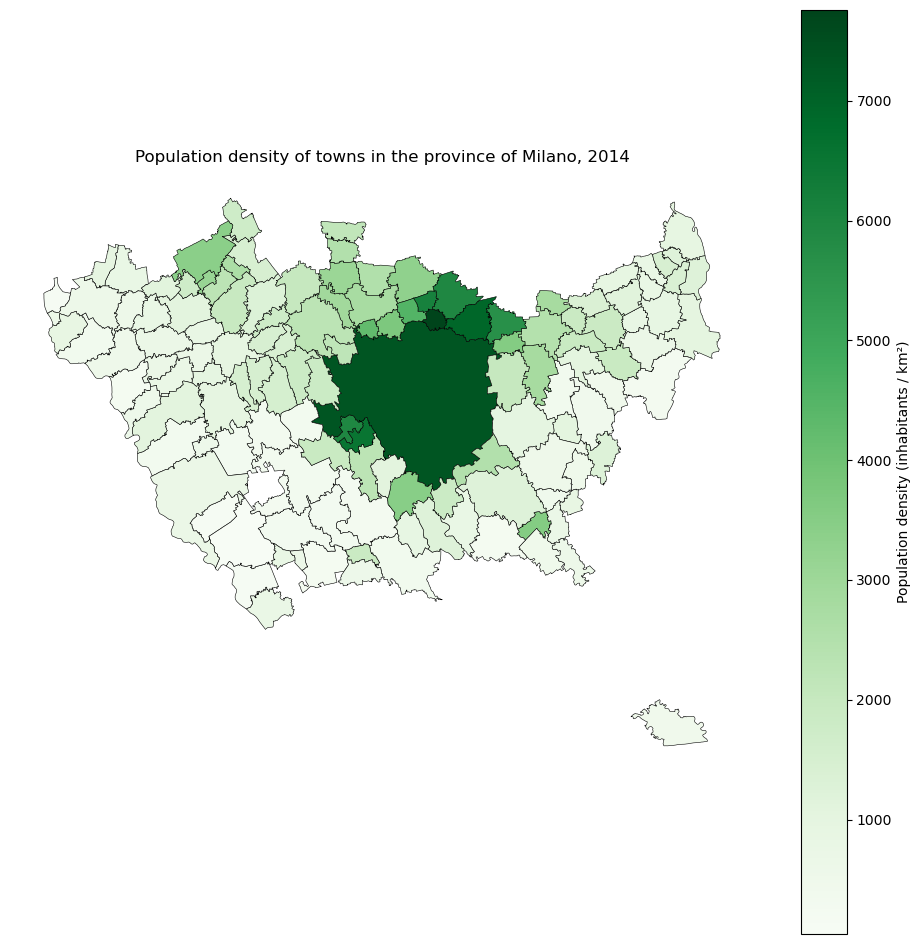

In [116]:
# density map
fig, ax = plt.subplots(figsize=(12, 12))

milano.plot(
    ax=ax,
    column='density_2014',
    cmap='Greens',
    legend=True,
    edgecolor='black',
    linewidth=0.4,
    legend_kwds={'label': 'Population density (inhabitants / km²)'}
)

ax.set_title('Population density of towns in the province of Milano, 2014')
ax.set_axis_off()

plt.show()